STOCK MARKET PREDICTION DATASET


The stock market plays a crucial role in the global economy, where investors aim to maximize profits by predicting future stock prices. However, stock prices are highly volatile and influenced by multiple factors such as market trends, company performance, economic conditions, and investor sentiment. Traditional prediction methods often fail to capture these complex patterns effectively.

Machine Learning (ML) provides powerful techniques to analyze large volumes of historical stock market data and identify hidden patterns that help in predicting future price movements. By using past data such as Open, High, Low, Close, Adjusted Close prices, and Trading Volume, ML models can learn trends and relationships within the data to make informed predictions.

This project focuses on building a stock market price prediction system using supervised machine learning algorithms. The objective is to predict future stock prices (or closing prices) based on historical data. The project involves data preprocessing, exploratory data analysis, feature selection, model training, and performance evaluation using appropriate metrics.

By implementing this project, we demonstrate how machine learning can assist investors and analysts in making data-driven decisions, reducing risk, and improving forecasting accuracy in stock market investments.

Tools & Libraries

1. Programming Language

Python
Python is used as the primary programming language due to its simplicity, extensive library support, and strong community for data science and machine learning applications.

2. Data Handling & Analysis

NumPy
Used for numerical computations and handling multi-dimensional arrays.

Pandas
Used for data loading, cleaning, preprocessing, and manipulation of stock market datasets.

3. Data Visualization

Matplotlib
Used to visualize stock price trends, moving averages, and model results.

Seaborn
Used for advanced statistical visualizations such as correlation heatmaps and distributions.

4. Machine Learning Libraries

Scikit-learn (sklearn)
Used for:

Train-test split

Feature scaling

Regression models (Linear Regression, Random Forest, SVR)

Model evaluation (MAE, MSE, RMSE, R² score)

6. Data Source & Dataset

Kaggle
Used to obtain historical stock market data including Open, High, Low, Close, Adjusted Close, and Volume.

In [2]:
from warnings import filterwarnings 
filterwarnings('ignore')
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,PolynomialFeatures,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,accuracy_score

Import dataset 

In [3]:
df=pd.read_csv(r"c:\Users\USER\Downloads\archive (18).zip")
print(df.head())

   Unnamed: 0       open       high        low      close   adjclose  \
0  2016-01-04  37.150002  37.202999  36.562901  37.091999  37.091999   
1  2016-01-05  37.322498  37.599998  36.931999  37.129002  37.129002   
2  2016-01-06  36.500000  37.359001  36.445999  37.181000  37.181000   
3  2016-01-07  36.515499  36.924999  35.952999  36.319500  36.319500   
4  2016-01-08  36.572498  36.661499  35.650002  35.723499  35.723499   

     volume ticker  
0  65456000   GOOG  
1  39014000   GOOG  
2  38940000   GOOG  
3  59274000   GOOG  
4  49018000   GOOG  


In [4]:
print(df.isnull().sum())
print(df.isnull().sum().sum())

Unnamed: 0    0
open          0
high          0
low           0
close         0
adjclose      0
volume        0
ticker        0
dtype: int64
0


In [5]:
df.duplicated().sum()

0

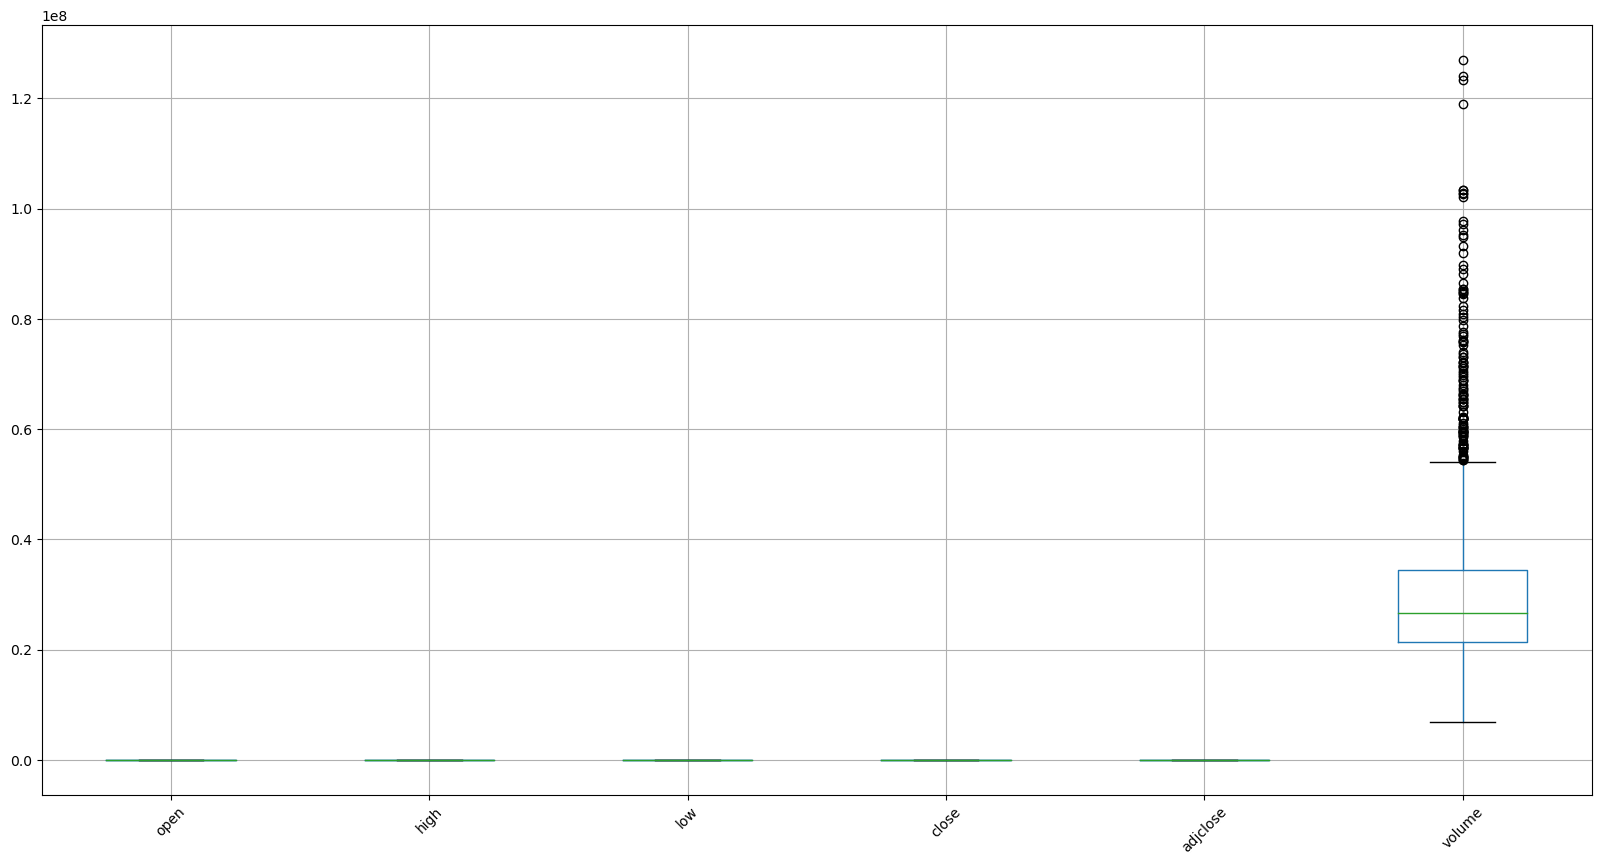

In [6]:
df.boxplot(figsize=(20,10))
plt.xticks(rotation=45)
plt.show()

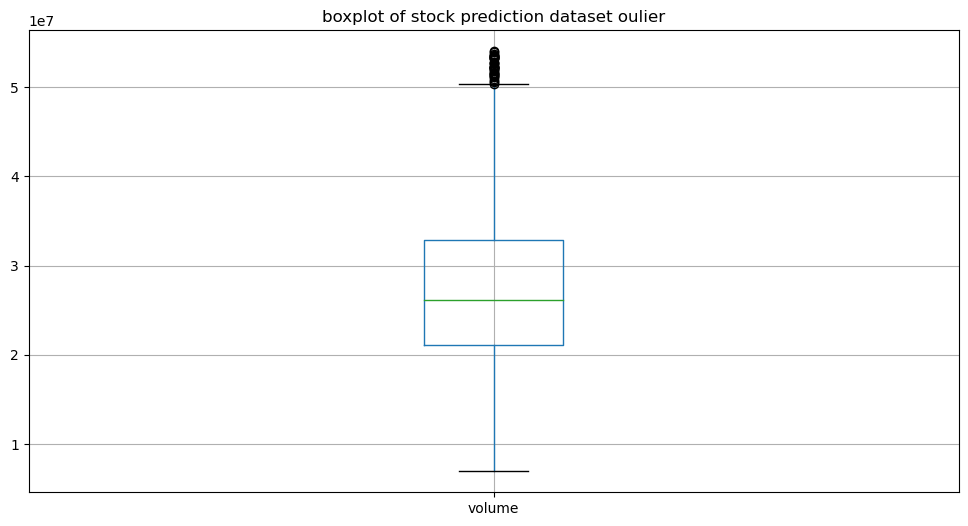

In [7]:
cols=['volume']
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df=df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]
    return df
df= cap_outliers_iqr(df,cols)
plt.figure(figsize=(12, 6))
df[cols].boxplot()   
plt.title('boxplot of stock prediction dataset oulier')
plt.show()

Basic information about dataset 

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1990 entries, 1 to 2112
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1990 non-null   object 
 1   open        1990 non-null   float64
 2   high        1990 non-null   float64
 3   low         1990 non-null   float64
 4   close       1990 non-null   float64
 5   adjclose    1990 non-null   float64
 6   volume      1990 non-null   int64  
 7   ticker      1990 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 139.9+ KB
None


Use summary statistics to understand distribution

In [9]:
print(df.describe())

              open         high          low        close     adjclose  \
count  1990.000000  1990.000000  1990.000000  1990.000000  1990.000000   
mean     83.662040    84.556975    82.885035    83.755588    83.755588   
std      37.895871    38.346245    37.497990    37.932506    37.932506   
min      33.549999    33.615002    33.164200    33.412998    33.412998   
25%      52.485499    53.048376    51.994000    52.454874    52.454874   
50%      70.974003    71.905251    70.342503    70.941750    70.941750   
75%     118.337500   119.886747   116.890003   118.847502   118.847502   
max     178.779999   179.949997   177.309998   179.539993   179.539993   

             volume  
count  1.990000e+03  
mean   2.782998e+07  
std    8.948989e+06  
min    6.936000e+06  
25%    2.115250e+07  
50%    2.615315e+07  
75%    3.284858e+07  
max    5.403650e+07  


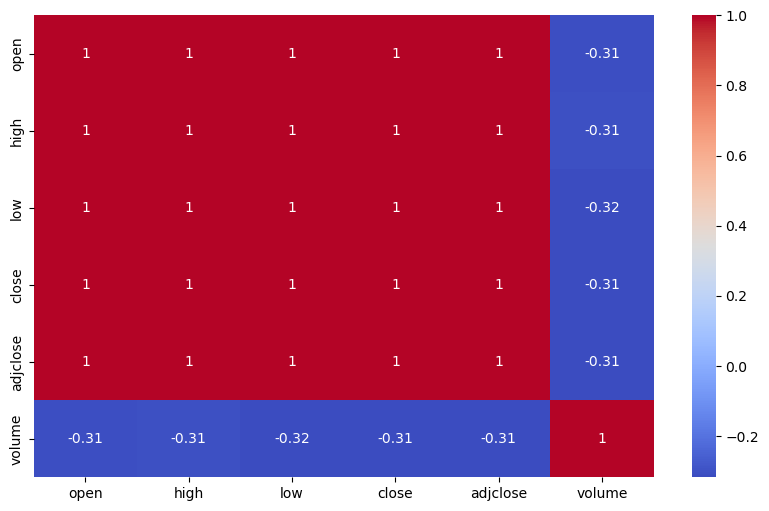

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [11]:
X = df.drop('close', axis=1)
y = df['close']   
X=df[['open','volume']]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:" , mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("R2 Score:", r2_score(y_test,y_pred))



MAE: 0.816242167523426
MSE: 1.4999426868638095
R2 Score: 0.9989994437031977


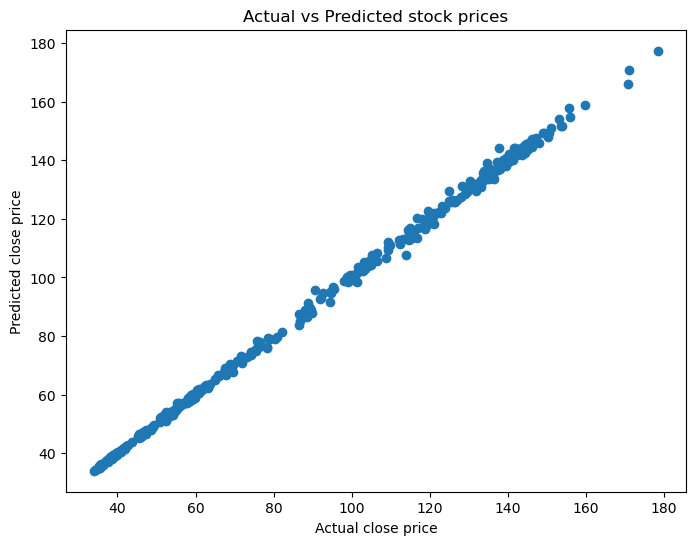

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual close price")
plt.ylabel("Predicted close price")
plt.title("Actual vs Predicted stock prices")
plt.show()

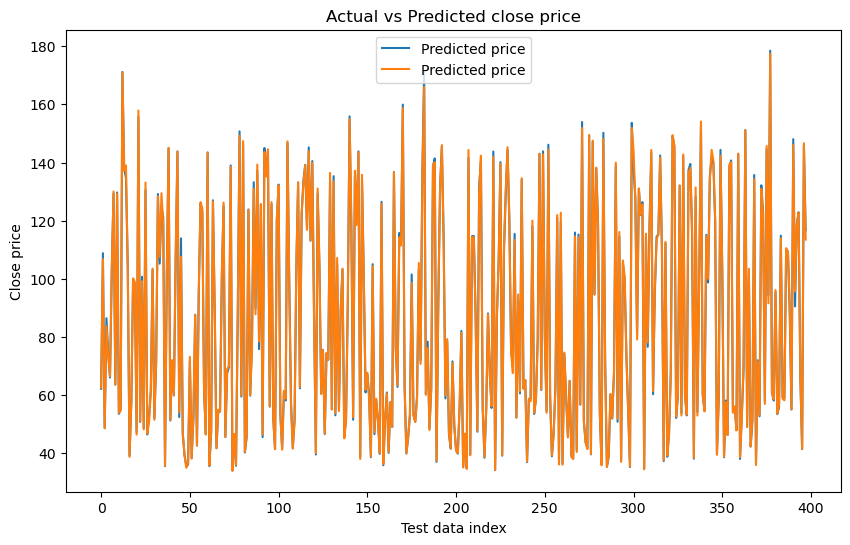

In [13]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Predicted price")
plt.plot(y_pred, label="Predicted price")
plt.xlabel("Test data index")
plt.ylabel("Close price")
plt.title("Actual vs Predicted close price")
plt.legend()
plt.show()

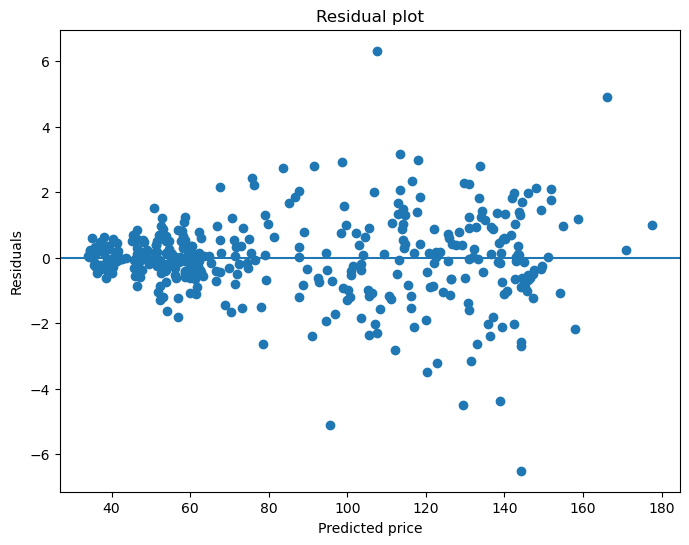

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals)
plt.axhline(y=0)
plt.xlabel("Predicted price")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

SUGGESTIONS AND RECOMMENDATIONS 

1️⃣ Data Improvements

Use longer historical data (5–10 years) to capture multiple market cycles.

Include adjusted close price instead of close price to handle splits and dividends.

Add technical indicators such as:

Moving Averages (SMA, EMA)

RSI (Relative Strength Index)

MACD

Bollinger Bands

Remove or cap outliers caused by abnormal market events if required.

2️⃣ Feature Engineering Suggestions

Create lag features (previous day, previous week prices).

Use returns (%) instead of raw prices for better stationarity.

Add volume-based features (volume change %, rolling averages).

Normalize or scale numerical features using:

StandardScaler

MinMaxScaler


3️⃣ Model Selection Recommendations

Start with baseline models:

Linear Regression

Decision Tree Regressor

Try advanced models:

Random Forest

XGBoost / Gradient Boosting

For time-series focus:

LSTM (if deep learning is allowed)

Compare multiple models instead of relying on one.


4️⃣ Train-Test Strategy

Use time-based split, not random split.

Example: Train on past data → Test on recent data

Apply walk-forward validation for better real-world performance.

Avoid data leakage from future values.